In [ ]:
# !pip install tensorflow

^C


Yang dilakukan :
1. Interpolasi: Mengisi data yang bolong/hilang (misal tertutup awan) menggunakan metode linear atau rata-rata tetangga
2. Normalisasi: Mengubah skala angka (misal suhu 20-40°C) menjadi rentang 0 sampai 1 agar mudah dibaca model
3. Sliding Window: Memotong data menjadi urutan waktu (misal: ambil data 7 hari ke belakang sebagai Input, dan hari ke-8 sebagai Target)
4. Tensor Stacking: Menyusun data menjadi format 5 Dimensi (Batch, Time, Height, Width, Channel) lalu menyimpannya menjadi file .npy

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
DATA_PATH = "../data/processed"
MODEL_SAVE_PATH = "../models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("⏳ Memuat dataset...")
X = np.load(os.path.join(DATA_PATH, "X_TRAIN_GRID.npy"))
y = np.load(os.path.join(DATA_PATH, "Y_TRAIN_GRID.npy"))

X[:, :, :, :, 1] = X[:, :, :, :, 1] / 50.0 # LST
X[:, :, :, :, 2] = X[:, :, :, :, 2] / 20.0 # Rain

print(f"✅ Data Loaded.")
print(f"   X Shape: {X.shape}") # (Sample, 7, H, W, 4)
print(f"   y Shape: {y.shape}") # (Sample, H, W, 1)

# Split Train/Val (80:20)
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"   Train Set: {len(X_train)} sampel")
print(f"   Val Set  : {len(X_val)} sampel")

⏳ Memuat dataset...
✅ Data Loaded.
   X Shape: (358, 7, 40, 46, 4)
   y Shape: (358, 40, 46, 1)
   Train Set: 286 sampel
   Val Set  : 72 sampel


In [ ]:
def weighted_binary_crossentropy(y_true, y_pred):
    bce = K.binary_crossentropy(y_true, y_pred)
    
    weight_vector = y_true * 20.0 + (1.0 - y_true) * 1.0
    
    weighted_bce = weight_vector * bce
    return K.mean(weighted_bce)

In [ ]:
model = Sequential()

model.add(ConvLSTM2D(filters=32, kernel_size=(3, 3),
                     input_shape=(X.shape[1], X.shape[2], X.shape[3], X.shape[4]),
                     padding='same', return_sequences=True, 
                     activation='relu'))
model.add(BatchNormalization())

model.add(ConvLSTM2D(filters=32, kernel_size=(3, 3),
                     padding='same', return_sequences=False, 
                     activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3)) 

model.add(Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu'))

model.add(Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid', padding='same'))

C:\Users\TheBe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(loss=weighted_binary_crossentropy, 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')])

model.summary()

checkpoint = ModelCheckpoint(
    os.path.join(MODEL_SAVE_PATH, "FireFinder_best_model.h5"), 
    monitor='val_recall', 
    verbose=1, 
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n🔥 MULAI TRAINING...")
history = model.fit(
    X_train, y_train,
    epochs=50, 
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stop]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 7, 40, 46, 32)  │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 40, 46, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 40, 46, 32)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 46, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 46, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,353 (470.13 KB)

 Trainable params: 120,225 (469.63 KB)

 Non-trainable params: 128 (512.00 B)

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 586ms/step - accuracy: 0.8722 - loss: 0.4802 - precision: 0.2419 - recall: 0.9057 - val_accuracy: 0.9401 - val_loss: 0.5309 - val_precision: 0.2520 - val_recall: 0.6390
Epoch 13/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.8559 - loss: 0.5033 - precision: 0.2324 - recall: 0.9198
Epoch 13: val_recall improved from 0.63900 to 0.71120, saving model to ../models\FireFinder_best_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 580ms/step - accuracy: 0.8673 - loss: 0.4833 - precision: 0.2357 - recall: 0.9116 - val_accuracy: 0.9229 - val_loss: 0.4976 - val_precision: 0.2138 - val_recall: 0.7112
Epoch 14/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8657 - loss: 0.4962 - precision: 0.2401 - recall: 0.9075
Epoch 14: val_recall improved from 0.71120 to 0.75554, saving model to ../models\FireFinder_best_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 584ms/step - accuracy: 0.8711 - loss: 0.4795 - precision: 0.2403 - recall: 0.9059 - val_accuracy: 0.9110 - val_loss: 0.4860 - val_precision: 0.1956 - val_recall: 0.7555
Epoch 15/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.8722 - loss: 0.4729 - precision: 0.2408 - recall: 0.9062
Epoch 15: val_recall improved from 0.75554 to 0.82092, saving model to ../models\FireFinder_best_model.h5


36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 674ms/step - accuracy: 0.8743 - loss: 0.4719 - precision: 0.2449 - recall: 0.9049 - val_accuracy: 0.8836 - val_loss: 0.4709 - val_precision: 0.1633 - val_recall: 0.8209
Epoch 16/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.8665 - loss: 0.4672 - precision: 0.2371 - recall: 0.9147
Epoch 16: val_recall did not improve from 0.82092
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 638ms/step - accuracy: 0.8675 - loss: 0.4694 - precision: 0.2364 - recall: 0.9152 - val_accuracy: 0.9133 - val_loss: 0.4677 - val_precision: 0.1996 - val_recall: 0.7524
Epoch 17/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.8685 - loss: 0.4952 - precision: 0.2484 - recall: 0.9053
Epoch 17: val_recall did not improve from 0.82092
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 761ms/step - accuracy: 0.8728 - loss: 0.4689 - precision: 0.2432 - recall: 0.9090 - val_accuracy: 0.9062 - val_loss: 0.4571 - val_precision: 0.1898 - val_recall: 0.7746
Epoch 18/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step

36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 827ms/step - accuracy: 0.8749 - loss: 0.4602 - precision: 0.2468 - recall: 0.9113 - val_accuracy: 0.8631 - val_loss: 0.4588 - val_precision: 0.1454 - val_recall: 0.8519
Epoch 20/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.8774 - loss: 0.4334 - precision: 0.2347 - recall: 0.9114
Epoch 20: val_recall did not improve from 0.85190
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 760ms/step - accuracy: 0.8728 - loss: 0.4551 - precision: 0.2441 - recall: 0.9158 - val_accuracy: 0.8801 - val_loss: 0.4700 - val_precision: 0.1590 - val_recall: 0.8189
Epoch 21/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.8815 - loss: 0.4424 - precision: 0.2473 - recall: 0.9062
Epoch 21: val_recall did not improve from 0.85190
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 763ms/step - accuracy: 0.8738 - loss: 0.4534 - precision: 0.2460 - recall: 0.9175 - val_accuracy: 0.8889 - val_loss: 0.4572 - val_precision: 0.1685 - val_recall: 0.8096
Epoch 22/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step


🔍 EVALUASI VISUAL (Mencari contoh kebakaran)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step


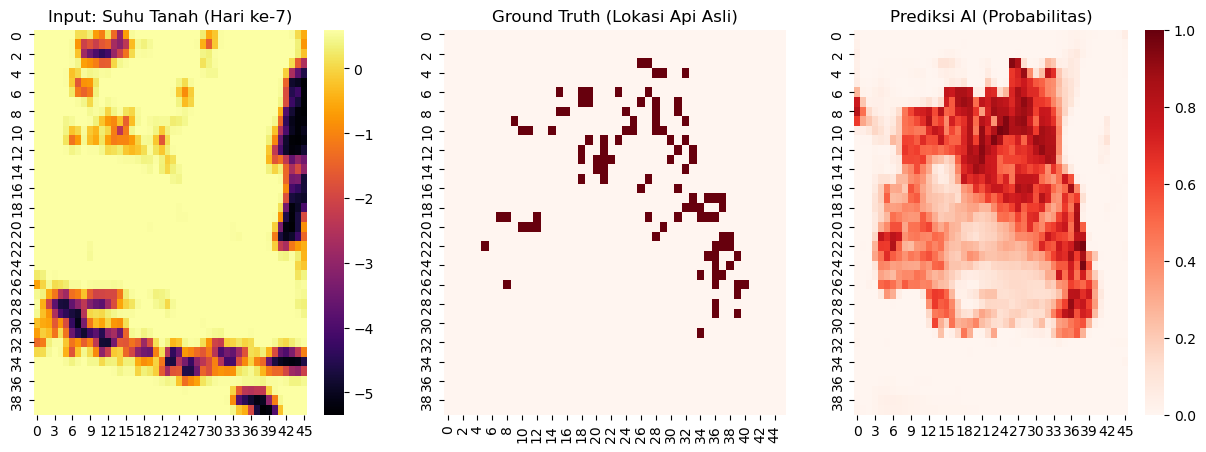

Keterangan: Semakin merah di Peta Prediksi, semakin yakin AI ada api di situ.

✅ Model tersimpan di: ../models\FireFinder_best_model.h5


In [ ]:
print("\n🔍 EVALUASI VISUAL (Mencari contoh kebakaran)...")

found_idx = -1
for i in range(len(y_val)):
    if np.sum(y_val[i]) > 0: 
        found_idx = i
        break

if found_idx != -1:
    sample_x = X_val[found_idx:found_idx+1]
    sample_y = y_val[found_idx] 
    
    pred_y = model.predict(sample_x)
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    sns.heatmap(sample_x[0, -1, :, :, 1], ax=ax[0], cmap='inferno', cbar=True)
    ax[0].set_title("Input: Suhu Tanah (Hari ke-7)")
    
    sns.heatmap(sample_y[:, :, 0], ax=ax[1], cmap='Reds', cbar=False, vmin=0, vmax=1)
    ax[1].set_title("Ground Truth (Lokasi Api Asli)")
    
    sns.heatmap(pred_y[0, :, :, 0], ax=ax[2], cmap='Reds', cbar=True, vmin=0, vmax=1)
    ax[2].set_title("Prediksi AI (Probabilitas)")
    
    plt.show()
    print("Keterangan: Semakin merah di Peta Prediksi, semakin yakin AI ada api di situ.")
else:
    print("Tidak ditemukan sampel kebakaran di data validasi (Mungkin semua di Training set).")

print(f"\n✅ Model tersimpan di: {os.path.join(MODEL_SAVE_PATH, 'FireFinder_best_model.h5')}")